# Test OCHumanLoader

Este notebook verifica que el `OCHumanLoader` funciona correctamente:

1. Carga las anotaciones del dataset OCHuman
2. Lee imágenes con bounding boxes y keypoints
3. Visualiza algunos ejemplos con keypoints anotados
4. Verifica la estructura de datos `ImageSample`

## 1. Import Libraries

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add project root to path
project_root = Path(os.getcwd()).parent
sys.path.insert(0, str(project_root / "src"))

from pose_uncertainty.data_loader import OCHumanLoader

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Configure Paths

In [2]:
# OCHuman dataset paths (relative to project root)
DATA_ROOT = project_root / "data" / "ochuman"
ANN_FILE = "annotations/ochuman_coco_format_val_range_0.00_1.00.json"
IMAGE_DIR = "images"

print(f"Data Root: {DATA_ROOT}")
print(f"Annotation File: {ANN_FILE}")
print(f"Image Directory: {IMAGE_DIR}")
print(f"\nChecking if files exist...")
print(f"  - Annotation exists: {(DATA_ROOT / ANN_FILE).exists()}")
print(f"  - Image dir exists: {(DATA_ROOT / IMAGE_DIR).exists()}")

Data Root: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\ochuman
Annotation File: annotations/ochuman_coco_format_val_range_0.00_1.00.json
Image Directory: images

Checking if files exist...
  - Annotation exists: True
  - Image dir exists: True


## 3. Initialize OCHumanLoader

In [3]:
loader = OCHumanLoader(
    data_root=str(DATA_ROOT),
    ann_file=ANN_FILE,
    image_dir=IMAGE_DIR
)

print(f"\n✓ OCHumanLoader initialized successfully")
print(f"  Total images available: {len(loader)}")

Cargando anotaciones desde c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\ochuman\annotations/ochuman_coco_format_val_range_0.00_1.00.json...
loading annotations into memory...
Done (t=0.34s)
creating index...
index created!
Dataset cargado: 2500 imágenes encontradas.

✓ OCHumanLoader initialized successfully
  Total images available: 2500


## 4. Load First Sample

In [4]:
# Get first sample from iterator
sample_iter = iter(loader)
sample = next(sample_iter)

print(f"Sample loaded successfully!")
print(f"  - Image ID: {sample.image_id}")
print(f"  - Image Path: {sample.image_path}")
print(f"  - Image Shape: {sample.image_array.shape}")
print(f"  - BBox (x,y,w,h): {sample.bbox}")
print(f"  - Dataset Source: {sample.dataset_source}")
print(f"  - Number of keypoints: {len(sample.ground_truth_keypoints)}")

Sample loaded successfully!
  - Image ID: 1
  - Image Path: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\ochuman\images\003799.jpg
  - Image Shape: (864, 900, 3)
  - BBox (x,y,w,h): (250, 112, 475, 751)
  - Dataset Source: ochuman
  - Number of keypoints: 17


## 5. Visualize Sample with Keypoints

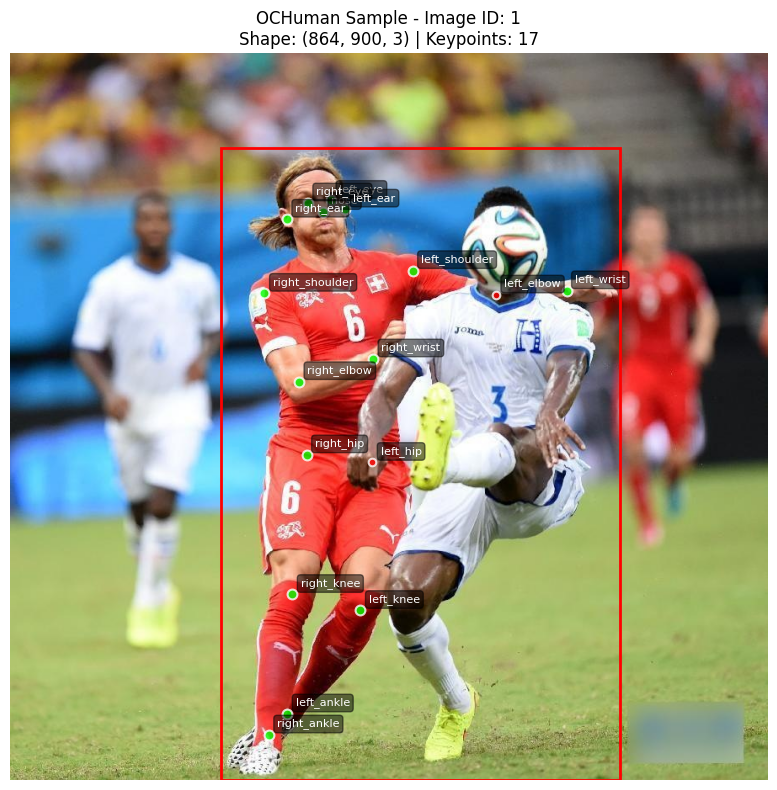

In [5]:
def visualize_sample(sample):
    """
    Visualize image with bounding box and keypoints.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Display image
    ax.imshow(sample.image_array)
    
    # Draw bounding box
    x, y, w, h = sample.bbox
    from matplotlib.patches import Rectangle
    rect = Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    
    # Draw keypoints with different colors based on confidence
    for kp in sample.ground_truth_keypoints:
        if kp.confidence > 0.0:
            # Color based on confidence: red (occluded) to green (visible)
            color = 'red' if kp.confidence == 0.5 else 'lime'
            size = 50 if kp.confidence == 1.0 else 30
            ax.scatter(kp.x, kp.y, c=color, s=size, alpha=0.8, edgecolors='white', linewidths=1.5)
            # Add keypoint name label
            ax.text(kp.x + 10, kp.y - 10, kp.name, color='white', 
                   fontsize=8, bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    
    ax.set_title(f"OCHuman Sample - Image ID: {sample.image_id}\n"
                 f"Shape: {sample.image_array.shape} | Keypoints: {len(sample.ground_truth_keypoints)}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_sample(sample)

## 6. Verify ImageSample Structure

In [6]:
print("=== ImageSample Structure ===")
print(f"Type: {type(sample)}")
print(f"\nAttributes:")
print(f"  - image_id: {sample.image_id} (type: {type(sample.image_id)})")
print(f"  - image_path: {sample.image_path}")
print(f"  - image_array: shape={sample.image_array.shape}, dtype={sample.image_array.dtype}")
print(f"  - bbox: {sample.bbox} (type: {type(sample.bbox)})")
print(f"  - dataset_source: {sample.dataset_source}")
print(f"  - ground_truth_keypoints: {len(sample.ground_truth_keypoints)} keypoints")

print(f"\n=== Sample Keypoints ===")
for i, kp in enumerate(sample.ground_truth_keypoints[:5]):  # Show first 5
    print(f"{i}. {kp.name}: ({kp.x:.1f}, {kp.y:.1f}) confidence={kp.confidence}")

=== ImageSample Structure ===
Type: <class 'pose_uncertainty.utils.types.ImageSample'>

Attributes:
  - image_id: 1 (type: <class 'int'>)
  - image_path: c:\Users\USUARIO\Desktop\Universidad\TFG_Informatica\robust-pose-tta\data\ochuman\images\003799.jpg
  - image_array: shape=(864, 900, 3), dtype=uint8
  - bbox: (250, 112, 475, 751) (type: <class 'tuple'>)
  - dataset_source: ochuman
  - ground_truth_keypoints: 17 keypoints

=== Sample Keypoints ===
0. nose: (371.6, 188.9) confidence=1.0
1. left_eye: (381.0, 174.6) confidence=1.0
2. right_eye: (353.4, 177.6) confidence=1.0
3. left_ear: (397.6, 184.9) confidence=1.0
4. right_ear: (328.5, 196.9) confidence=1.0


## 7. Statistics: Keypoint Visibility

In [ ]:
# Count keypoints by confidence level
not_labeled = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.0)
occluded = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 0.5)
visible = sum(1 for kp in sample.ground_truth_keypoints if kp.confidence == 1.0)

print("=== Keypoint Visibility Statistics ===")
print(f"Not labeled (v=0): {not_labeled}")
print(f"Occluded (v=1): {occluded}")
print(f"Visible (v=2): {visible}")
print(f"Total: {len(sample.ground_truth_keypoints)}")

# Visualize distribution
labels = ['Not Labeled\n(v=0)', 'Occluded\n(v=1)', 'Visible\n(v=2)']
counts = [not_labeled, occluded, visible]
colors = ['gray', 'red', 'lime']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Keypoint Visibility Distribution (OCHuman Sample)')
ax.set_ylim(0, max(counts) + 2)

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Test Lazy Loading

In [ ]:
import time

print("=== Testing Lazy Loading ===")
print("Iterating through first 10 samples...\n")

start_time = time.time()
count = 0

for i, sample in enumerate(loader):
    if i >= 10:
        break
    count += 1
    print(f"Sample {i+1}: Image ID {sample.image_id}, Shape {sample.image_array.shape}")

elapsed = time.time() - start_time
print(f"\n✓ Successfully loaded {count} samples in {elapsed:.2f} seconds")
print(f"  Average time per sample: {elapsed/count:.3f}s")

## 9. Visualize Multiple Samples

In [ ]:
def visualize_grid(loader, num_samples=6):
    """
    Visualize multiple samples in a grid.
    """
    samples = []
    for i, sample in enumerate(loader):
        if i >= num_samples:
            break
        samples.append(sample)
    
    rows = 2
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, sample in enumerate(samples):
        ax = axes[idx]
        ax.imshow(sample.image_array)
        
        # Draw keypoints
        for kp in sample.ground_truth_keypoints:
            if kp.confidence > 0.0:
                color = 'red' if kp.confidence == 0.5 else 'lime'
                size = 40 if kp.confidence == 1.0 else 25
                ax.scatter(kp.x, kp.y, c=color, s=size, alpha=0.8, 
                          edgecolors='white', linewidths=1)
        
        # Draw bbox
        x, y, w, h = sample.bbox
        from matplotlib.patches import Rectangle
        rect = Rectangle((x, y), w, h, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        
        ax.set_title(f"ID: {sample.image_id}")
        ax.axis('off')
    
    plt.suptitle('OCHuman Dataset - Sample Grid', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_grid(loader, num_samples=6)

## 10. Summary

In [ ]:
print("="*60)
print("OCHUMAN LOADER TEST SUMMARY")
print("="*60)
print(f"✓ OCHumanLoader successfully loaded {len(loader)} images")
print(f"✓ Each sample contains:")
print(f"  - Image array (RGB format)")
print(f"  - Bounding box [x, y, w, h]")
print(f"  - 17 keypoints with names and confidence")
print(f"  - Dataset source identifier: 'ochuman'")
print(f"\n✓ Lazy loading verified: Images loaded on-demand")
print(f"✓ Visualization working: Keypoints displayed correctly")
print(f"\n🎯 OCHumanLoader is ready for use in the pipeline!")
print("="*60)